# Seaborn Statistical Visualizations: Beginner-Friendly Revision Guide
Discover how Seaborn makes beautiful statistical charts simple: Histograms, Density Curves (KDE), Boxplots, Violins, Swarms, and Regression trends.

### 📚 What You Will Learn in this Guide:
- **Distribution Analysis (`histplot`, `kdeplot`, `ecdfplot`, `rugplot`)**: How to explore data distributions and density curves with zero boilerplate.
- **Categorical Summaries (`boxplot`, `violinplot`, `stripplot`, `swarmplot`, `barplot`)**: How to compare groups, medians, quartiles, and outliers effortlessly.
- **Relational Plotting (`scatterplot`, `lineplot`, `regplot`)**: How to map multi-variable relationships and add linear regression trendlines.

> **💡 Beginner Note**: Every single concept is isolated in its own section with:
> 1. **What is this?** (Plain English explanation)
> 2. **Why do we use it?** (Real-world intuition)
> 3. **Syntax & Parameters** (Parameter-by-parameter breakdown)
> 4. **Live Python Code** with outputs using `data/raw_transactions.csv`.

In [1]:
# Step 1: Import all necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Step 2: Set clean visual defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

# Step 3: Load the transactions dataset
csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)

# Step 4: Ensure dates and numeric values are clean
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"✅ Successfully loaded {len(df)} transactions from {csv_path}")
df.head(3)

✅ Successfully loaded 14262 transactions from data/raw_transactions.csv


## 🔹 Distribution Histogram: `sns.histplot()`

### 1. What is this?
`sns.histplot()` automatically groups data into bins and can overlay a smooth density curve (`kde=True`).

### 2. Why do we use it?
It is the single fastest way to see how your numeric data is distributed.

### 3. Syntax & Parameters
```python
sns.histplot(data=df, x='column_name', hue='category', kde=True, palette='Set2')
```

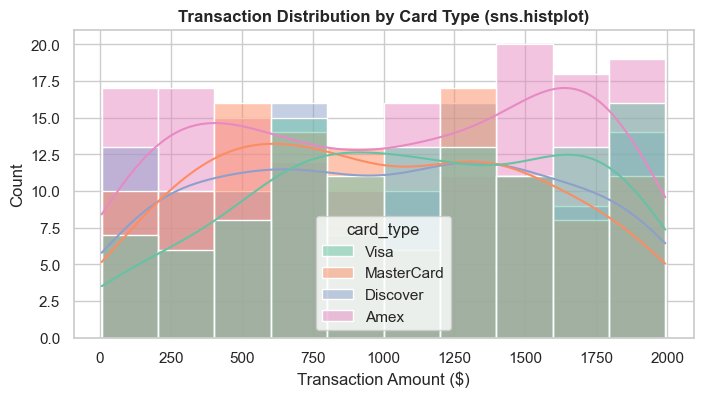

In [2]:
# 1. Plot amount distribution with a smooth curve
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df.head(500), x='transaction_amount', hue='card_type', kde=True, ax=ax, palette='Set2')
ax.set_title('Transaction Distribution by Card Type (sns.histplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')

plt.show()

## 🔹 Kernel Density Estimation: `sns.kdeplot()`

### 1. What is this?
`sns.kdeplot()` estimates a continuous smooth probability density curve without drawing boxy histogram bars.

### 2. Why do we use it?
Use KDE plots to compare the probability shapes of different groups (e.g. *Legitimate vs. Fraudulent transactions*).

### 3. Syntax & Parameters
```python
sns.kdeplot(data=df, x='column', hue='group', fill=True, palette='coolwarm')
```

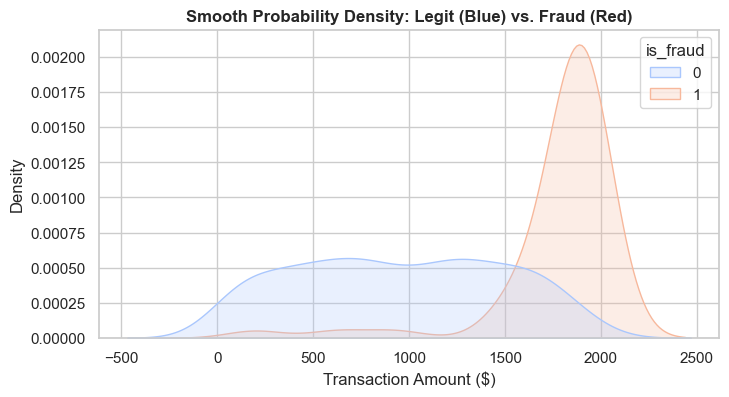

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(df.head(500), x='transaction_amount', hue='is_fraud', fill=True, common_norm=False, palette='coolwarm', ax=ax)
ax.set_title('Smooth Probability Density: Legit (Blue) vs. Fraud (Red)', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')

plt.show()

## 🔹 Boxplots: `sns.boxplot()`

### 1. What is this?
A boxplot summarizes 5 key numbers:
- The minimum
- The 25th percentile (Q1)
- The median (50th percentile)
- The 75th percentile (Q3)
- Outliers (dots beyond the whiskers).

### 2. Why do we use it?
Use boxplots to instantly spot outliers and compare medians across categories.

### 3. Syntax & Parameters
```python
sns.boxplot(data=df, x='category', y='amount', hue='subgroup')
```

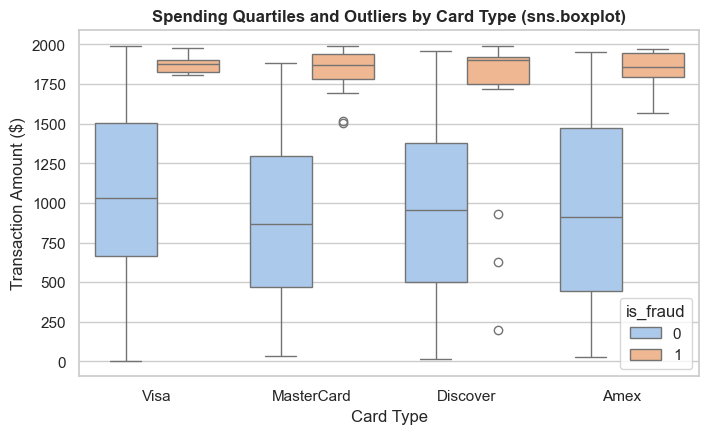

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', palette='pastel', ax=ax)
ax.set_title('Spending Quartiles and Outliers by Card Type (sns.boxplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

## 🔹 Violin Plots: `sns.violinplot()`

### 1. What is this?
A violin plot combines a boxplot with a mirrored density curve (KDE), showing both the summary statistics and the exact shape of the data.

### 2. Why do we use it?
Use violin plots when data has multiple peaks (bimodal) that a boxplot might hide.

### 3. Syntax & Parameters
```python
sns.violinplot(data=df, x='category', y='amount', split=True)
```

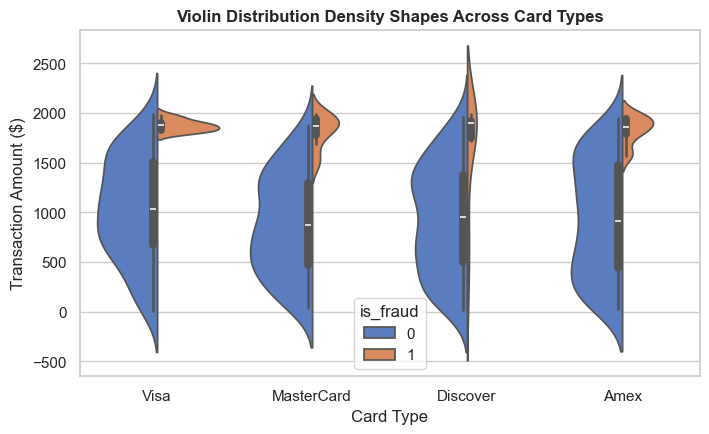

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(df.head(500), x='card_type', y='transaction_amount', hue='is_fraud', split=True, palette='muted', ax=ax)
ax.set_title('Violin Distribution Density Shapes Across Card Types', fontsize=12, fontweight='bold')
ax.set_xlabel('Card Type')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

## 🔹 Categorical Strip & Swarm Plots: `sns.stripplot()` & `sns.swarmplot()`

### 1. What is this?
`stripplot` draws scatter dots for each category with small jitter. `swarmplot` arranges the dots neatly side-by-side so none overlap.

### 2. Why do we use it?
Great for smaller datasets where you want to see every individual customer or transaction.

### 3. Syntax & Parameters
```python
sns.stripplot(data=df, x='region', y='amount', jitter=True)
sns.swarmplot(data=df, x='region', y='amount')
```

<string>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




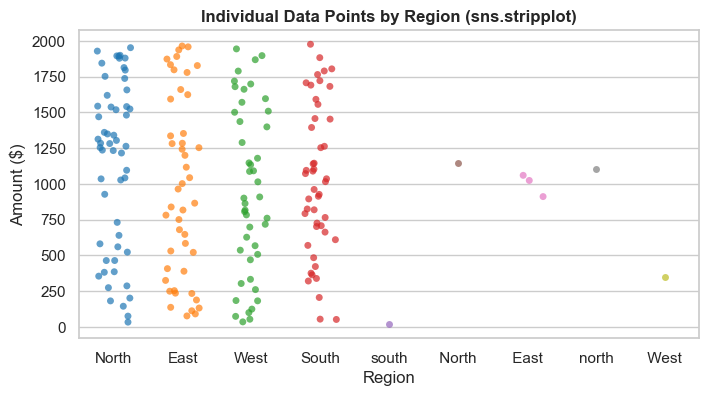

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(df.head(200), x='region', y='transaction_amount', jitter=0.25, alpha=0.7, palette='tab10', ax=ax)
ax.set_title('Individual Data Points by Region (sns.stripplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Amount ($)')

plt.show()

## 🔹 Bar Plot with 95% Confidence Intervals: `sns.barplot()`

### 1. What is this?
Unlike Matplotlib which requires manual error calculations, `sns.barplot()` computes category averages and automatically draws 95% bootstrapped confidence interval error bars.

### 2. Why do we use it?
Standard for reporting business metrics and experimental A/B testing results.

### 3. Syntax & Parameters
```python
sns.barplot(data=df, x='region', y='amount', hue='is_fraud')
```

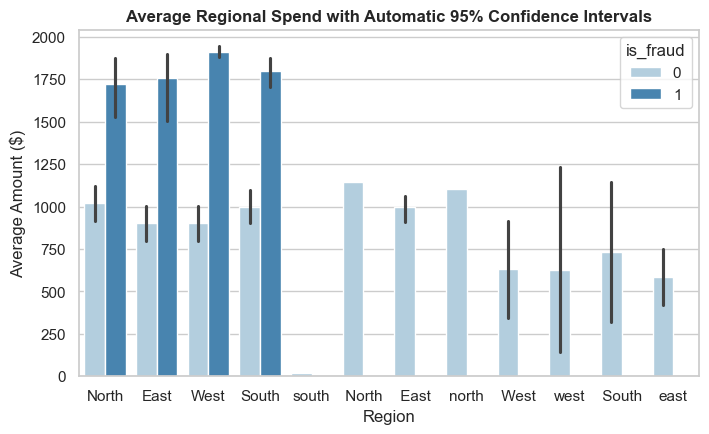

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(df.head(500), x='region', y='transaction_amount', hue='is_fraud', palette='Blues', ax=ax)
ax.set_title('Average Regional Spend with Automatic 95% Confidence Intervals', fontsize=12, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Average Amount ($)')

plt.show()

## 🔹 Scatter Plot with Multi-Encoding: `sns.scatterplot()`

### 1. What is this?
`sns.scatterplot()` lets you map multiple variables to color (`hue`), dot size (`size`), and marker shape (`style`) with a single line of code.

### 2. Why do we use it?
Explore 4 or 5 dimensions simultaneously in one 2D chart.

### 3. Syntax & Parameters
```python
sns.scatterplot(data=df, x='age', y='amount', hue='card', size='amount', style='fraud')
```

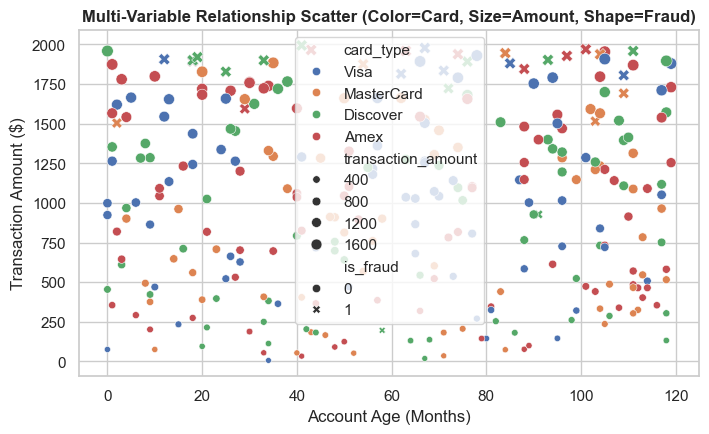

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.scatterplot(
    data=df.head(300), 
    x='account_age_months', 
    y='transaction_amount', 
    hue='card_type', 
    size='transaction_amount', 
    style='is_fraud', 
    ax=ax
)
ax.set_title('Multi-Variable Relationship Scatter (Color=Card, Size=Amount, Shape=Fraud)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')

plt.show()

## 🔹 Linear Regression Best-Fit: `sns.regplot()`

### 1. What is this?
`sns.regplot()` plots scatter dots and automatically fits and draws a linear regression trendline with a 95% shaded confidence interval band.

### 2. Why do we use it?
Use it to quickly see if there is a positive or negative linear trend between two variables.

### 3. Syntax & Parameters
```python
sns.regplot(data=df, x='x_col', y='y_col', color='purple')
```

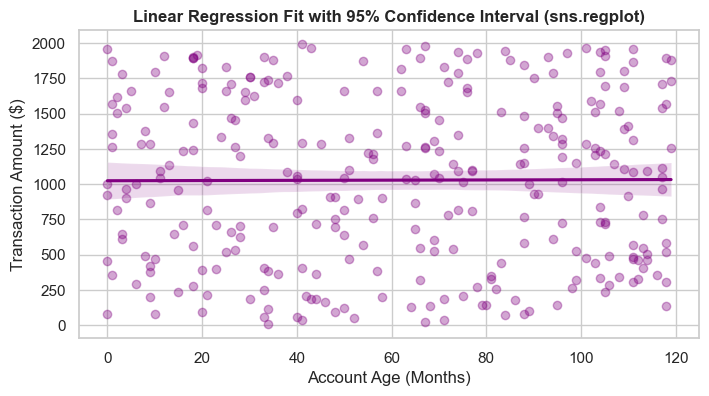

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.regplot(data=df.head(300), x='account_age_months', y='transaction_amount', color='purple', scatter_kws={'alpha':0.35}, ax=ax)
ax.set_title('Linear Regression Fit with 95% Confidence Interval (sns.regplot)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')

plt.show()